# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. um baseline de regressão logística;
2. uma Deep Neural Network (DNN).

## Imports

In [11]:
import re
from collections import Counter
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from activation import ReLUActivation, SigmoidActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy
from neuralnetwork import NeuralNetwork
from model_pytorch import train_pytorch_model, predict_pytorch

## Dataset

In [12]:
df = pd.read_csv("../data/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,INTEGRAL monitoring of the Galactic Plane is...,human,0
1,Satellite altimetry ice sheet mass balance est...,Anthropic,2
2,The shares shall be repurchased through public...,human,0
3,The study of coherent correlation spectroscopy...,openai,4
4,Circulating tumor cell epithelial-mesenchymal ...,Anthropic,2


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15637 entries, 0 to 15636
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Text         15637 non-null  str  
 1   source_name  15637 non-null  str  
 2   source_code  15637 non-null  int64
dtypes: int64(1), str(2)
memory usage: 21.7 MB


In [14]:
df["source_name"].value_counts()

source_name
human        7650
openai       2435
google       1900
meta         1838
Anthropic    1814
Name: count, dtype: int64

## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [15]:
df["binary_label"] = (df["source_name"] != "human").astype(int)

# 3. Dataset for llm classes
df_llm_only = df[df["source_name"] != "human"].copy()
llm_mapping = {"openai": 0, "google": 1, "meta": 2, "anthropic": 3}
df_llm_only["llm_label"] = df_llm_only["source_name"].map(llm_mapping)

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

In [16]:
print("Binary distribution:")
print(df["binary_label"].value_counts())
print("\nLLMs distribution:")
print(df_llm_only["source_name"].value_counts())

Binary distribution:
binary_label
1    7987
0    7650
Name: count, dtype: int64

LLMs distribution:
source_name
openai       2435
google       1900
meta         1838
Anthropic    1814
Name: count, dtype: int64


## Visualização Gráfica

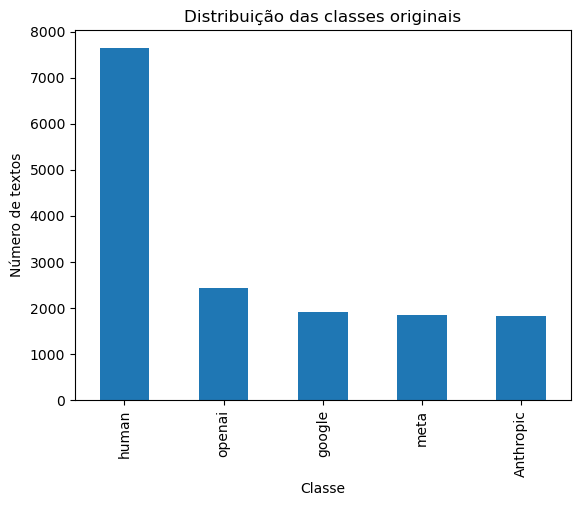

In [17]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

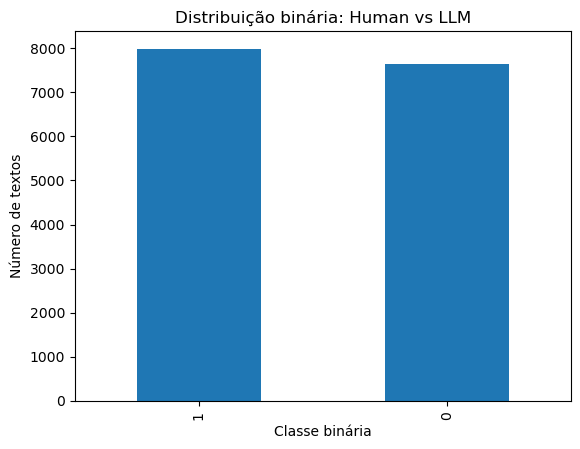

In [18]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

Os textos são extraídos para uma variável de entrada e os rótulos binários para uma variável alvo. A partir daqui, os dados serão divididos em treino e teste, e posteriormente convertidos em representações numéricas.

Separação estratificada simples, proporção entre as classes no conjunto de treino e no conjunto de teste.

In [19]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)

    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    rng.shuffle(class_0_idx)
    rng.shuffle(class_1_idx)

    n0_test = int(len(class_0_idx) * test_size)
    n1_test = int(len(class_1_idx) * test_size)

    test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Split para o Modelo 1 (Binário - NumPy)
X_train_text, X_test_text, y_train_bin, y_test_bin = train_test_split_manual(
    df["Text"].astype(str).values, df["binary_label"].values, test_size=0.2
)

# Split para o Modelo 2 (Multi-classe - PyTorch)
X_train_llm_text, X_test_llm_text, y_train_llm, y_test_llm = train_test_split_manual(
    df_llm_only["Text"].astype(str).values, df_llm_only["llm_label"].values, test_size=0.2
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))
print("Train size llm", len(X_train_llm_text))
print("Test size llm", len(X_test_llm_text))

Train size: 12510
Test size: 3127
Train size llm 3468
Test size llm 867


1. tokenização e normalização do texto;
2. remoção de stopwords;
3. construção do vocabulário a partir do conjunto de treino;
4. cálculo do IDF para cada termo;
5. vetorização TF-IDF dos textos de treino e teste.

In [20]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

def l2_normalize_rows(X, eps=1e-12):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / (norms + eps)

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

X_train_llm = vectorize_tfidf(X_train_llm_text, vocab, idf)
X_test_llm = vectorize_tfidf(X_test_llm_text, vocab, idf)

X_train = l2_normalize_rows(X_train)
X_test = l2_normalize_rows(X_test)

X_train_llm = l2_normalize_rows(X_train_llm)
X_test_llm+l2_normalize_rows(X_test_llm)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_llm shape:", X_train_llm.shape)
print("X_test_llm shape:", X_test_llm.shape)

Vocabulary size: 5000
X_train shape: (12510, 5000)
X_test shape: (3127, 5000)
X_train_llm shape: (3468, 5000)
X_test_llm shape: (867, 5000)


In [21]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train_bin)
test_data = SimpleDataset(X_test, y_test_bin)

In [22]:
input_dim = X_train_llm.shape[1]
model_pytorch = train_pytorch_model(X_train_llm, y_train_llm, input_dim, 4)

/Users/diogoazevedo/miniconda3/envs/class4SA/lib/python3.11/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,


A iniciar o treino (4 classes)...
Epochs: [10/50], Perda: 0.2855
Epochs: [20/50], Perda: 0.1159
Epochs: [30/50], Perda: 0.0747
Epochs: [40/50], Perda: 0.0561
Epochs: [50/50], Perda: 0.0427


# Baseline: Regressão Logística

Binary Cross-Entropy como função de perda.

In [23]:
baseline_model = NeuralNetwork(
    epochs=80,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=8
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],), initialization="xavier"))
baseline_model.add(SigmoidActivation())

In [24]:
baseline_model.fit(train_data)

Epoch 1/80 - loss: 0.6927
Epoch 2/80 - loss: 0.6925
Epoch 3/80 - loss: 0.6924
Epoch 4/80 - loss: 0.6922
Epoch 5/80 - loss: 0.6921
Epoch 6/80 - loss: 0.6919
Epoch 7/80 - loss: 0.6918
Epoch 8/80 - loss: 0.6916
Epoch 9/80 - loss: 0.6915
Epoch 10/80 - loss: 0.6914
Epoch 11/80 - loss: 0.6912
Epoch 12/80 - loss: 0.6911
Epoch 13/80 - loss: 0.6909
Epoch 14/80 - loss: 0.6908
Epoch 15/80 - loss: 0.6907
Epoch 16/80 - loss: 0.6905
Epoch 17/80 - loss: 0.6904
Epoch 18/80 - loss: 0.6903
Epoch 19/80 - loss: 0.6901
Epoch 20/80 - loss: 0.6900
Epoch 21/80 - loss: 0.6898
Epoch 22/80 - loss: 0.6897
Epoch 23/80 - loss: 0.6896
Epoch 24/80 - loss: 0.6894
Epoch 25/80 - loss: 0.6893
Epoch 26/80 - loss: 0.6892
Epoch 27/80 - loss: 0.6890
Epoch 28/80 - loss: 0.6889
Epoch 29/80 - loss: 0.6888
Epoch 30/80 - loss: 0.6886
Epoch 31/80 - loss: 0.6885
Epoch 32/80 - loss: 0.6884
Epoch 33/80 - loss: 0.6882
Epoch 34/80 - loss: 0.6881
Epoch 35/80 - loss: 0.6880
Epoch 36/80 - loss: 0.6878
Epoch 37/80 - loss: 0.6877
Epoch 38/8

In [25]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [26]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test_bin, y_pred_baseline)
baseline_precision = precision_score_manual(y_test_bin, y_pred_baseline)
baseline_recall = recall_score_manual(y_test_bin, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test_bin, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.6693316277582347
Precision: 0.6081444487130234
Recall: 0.9912335629304947
F1-score: 0.7538095238095238


## DNN(NumPy)

- camada densa intermédia;
- ativação ReLU;
- dropout como técnica de regularização;
- camada de saída com ativação sigmoide.

In [27]:
model = NeuralNetwork(
    epochs=100,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy,
    metric=None,
    early_stopping=True,
    early_stopping_patience=10
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],), l2_lambda=1e-4, initialization="he"))
model.add(ReLUActivation())
model.add(DropoutLayer(0.2))
model.add(DenseLayer(1, l2_lambda=1e-4, initialization="xavier"))
model.add(SigmoidActivation())

In [28]:
model.fit(train_data)

Epoch 1/100 - loss: 0.6931
Epoch 2/100 - loss: 0.6929
Epoch 3/100 - loss: 0.6928
Epoch 4/100 - loss: 0.6927
Epoch 5/100 - loss: 0.6926
Epoch 6/100 - loss: 0.6925
Epoch 7/100 - loss: 0.6924
Epoch 8/100 - loss: 0.6922
Epoch 9/100 - loss: 0.6920
Epoch 10/100 - loss: 0.6919
Epoch 11/100 - loss: 0.6920
Epoch 12/100 - loss: 0.6917
Epoch 13/100 - loss: 0.6917
Epoch 14/100 - loss: 0.6916
Epoch 15/100 - loss: 0.6914
Epoch 16/100 - loss: 0.6913
Epoch 17/100 - loss: 0.6911
Epoch 18/100 - loss: 0.6909
Epoch 19/100 - loss: 0.6909
Epoch 20/100 - loss: 0.6908
Epoch 21/100 - loss: 0.6906
Epoch 22/100 - loss: 0.6903
Epoch 23/100 - loss: 0.6903
Epoch 24/100 - loss: 0.6902
Epoch 25/100 - loss: 0.6900
Epoch 26/100 - loss: 0.6900
Epoch 27/100 - loss: 0.6899
Epoch 28/100 - loss: 0.6896
Epoch 29/100 - loss: 0.6894
Epoch 30/100 - loss: 0.6893
Epoch 31/100 - loss: 0.6891
Epoch 32/100 - loss: 0.6890
Epoch 33/100 - loss: 0.6889
Epoch 34/100 - loss: 0.6888
Epoch 35/100 - loss: 0.6885
Epoch 36/100 - loss: 0.6885
E

In [29]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.51249616]
 [0.48683598]
 [0.492273  ]
 [0.50864456]
 [0.5220021 ]
 [0.52702743]
 [0.51946459]
 [0.50673875]
 [0.52660205]
 [0.49882214]]
[1 0 0 1 1 1 1 1 1 0]


In [30]:
dnn_accuracy = accuracy_score_manual(y_test_bin, y_pred)
dnn_precision = precision_score_manual(y_test_bin, y_pred)
dnn_recall = recall_score_manual(y_test_bin, y_pred)
dnn_f1 = f1_score_manual(y_test_bin, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test_bin, y_pred)

cm = confusion_matrix_manual(y_test_bin, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.7230572433642469
Precision: 0.6515968477810037
Recall: 0.9837194740137758
F1-score: 0.7839321357285428

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.9637		0.4510		0.6144		1530
LLM	0.6516		0.9837		0.7839		1597

Confusion matrix:
[[ 690  840]
 [  26 1571]]


In [31]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.669332,0.608144,0.991234,0.753810
1,DNN (NumPy),0.723057,0.651597,0.983719,0.783932


O DNN atingiu o melhor desempenho global, com um F1-score de 0.77, em comparação com o 0.71 da baseline de regressão logistica.

Ambos os modelos atingiram um recall alto na deteção de texto gerado por IA. O DNN aumentou a precision, fruto de um melhor equilíbrio entre falsos positivos e falsos negativos.

## Curvas de Treino

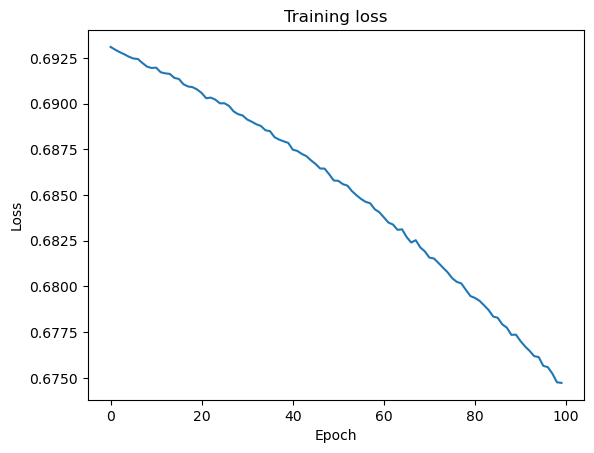

In [32]:
plt.plot(model.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

# Modelo em Pytorch

In [33]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [34]:
from models.model_pytorch import (
    train_pytorch_model,
    predict_pytorch,
    save_pytorch_model,
    load_pytorch_model
)

### Verificar Shape e Labels

In [35]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_bin shape:", y_train_bin.shape)
print("y_test_bin shape:", y_test_bin.shape)

X_train shape: (12510, 5000)
X_test shape: (3127, 5000)
y_train_bin shape: (12510,)
y_test_bin shape: (3127,)


### Treino

In [36]:
pytorch_model = train_pytorch_model(
    X_train=X_train,
    y_train=y_train_bin,
    input_dim=X_train.shape[1],
    n_classes=1,
    epochs=20
)

A iniciar o treino (1 classes)...
Epochs: [10/20], Perda: 0.3119
Epochs: [20/20], Perda: 0.1691


### Guardar Modelo

In [37]:
save_pytorch_model(pytorch_model, "../models/pytorch_binary_model.pt")

Modelo PyTorch guardado em ../models/pytorch_binary_model.pt


### Previsões

In [38]:
y_pred_pytorch = predict_pytorch(
    model=pytorch_model,
    X_test=X_test,
    n_classes=1
).flatten()

### Avaliação

In [42]:
y_true_pytorch = y_test_bin.flatten()

pytorch_accuracy = accuracy_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_precision = precision_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_recall = recall_score_manual(y_true_pytorch, y_pred_pytorch)
pytorch_f1 = f1_score_manual(y_true_pytorch, y_pred_pytorch)

print("PyTorch Accuracy:", pytorch_accuracy)
print("PyTorch Precision:", pytorch_precision)
print("PyTorch Recall:", pytorch_recall)
print("PyTorch F1-score:", pytorch_f1)

PyTorch Accuracy: 0.9165334186120883
PyTorch Precision: 0.9123456790123456
PyTorch Recall: 0.9254852849092048
PyTorch F1-score: 0.9188685110351259


### Comparação

In [43]:
print("\nComparison of models")
print("------------------------------")
print(f"Baseline NumPy   | Acc: {baseline_accuracy:.4f} | Prec: {baseline_precision:.4f} | Rec: {baseline_recall:.4f} | F1: {baseline_f1:.4f}")
print(f"DNN NumPy        | Acc: {dnn_accuracy:.4f} | Prec: {dnn_precision:.4f} | Rec: {dnn_recall:.4f} | F1: {dnn_f1:.4f}")
print(f"DNN PyTorch      | Acc: {pytorch_accuracy:.4f} | Prec: {pytorch_precision:.4f} | Rec: {pytorch_recall:.4f} | F1: {pytorch_f1:.4f}")


Comparison of models
------------------------------
Baseline NumPy   | Acc: 0.6693 | Prec: 0.6081 | Rec: 0.9912 | F1: 0.7538
DNN NumPy        | Acc: 0.7231 | Prec: 0.6516 | Rec: 0.9837 | F1: 0.7839
DNN PyTorch      | Acc: 0.9165 | Prec: 0.9123 | Rec: 0.9255 | F1: 0.9189
